In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Berhasil memuat dataset. Jumlah baris awal: 1780

=== Tahap 1: Analisis Panjang Teks & Segmentasi ===
Rata-rata jumlah kata per ulasan awal: 62.62 kata
Jumlah data setelah segmentasi: 9700

=== Tahap 2: Deteksi Bahasa ===
Distribusi Bahasa dalam Dataset:
language
id         8278
so          336
unknown     299
tl          227
sw           93
en           64
sl           46
et           36
fi           33
af           27
ca           24
da           22
pt           19
lt           19
hr           17
it           17
tr           17
es           16
sq           15
sk           15
ro           15
no           11
pl           10
lv           10
sv           10
cy            7
de            6
fr            4
nl            3
hu            3
cs            1
Name: count, dtype: int64


=== Tahap 3: Visualisasi & Perhitungan Frekuensi Kata ===

--- [BAHASA INDONESIA] ---
 File frekuensi kata berhasil tersimpan di: 'frekuensi_kata_awal_id.csv'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124

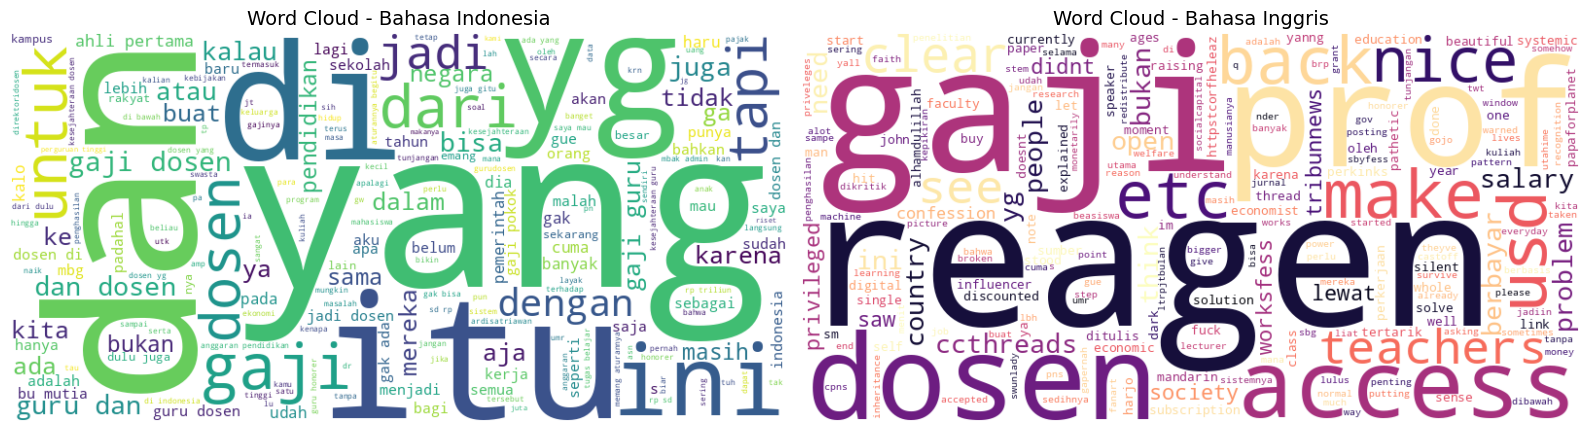

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect
from wordcloud import WordCloud
import nltk
import re
from collections import Counter

# Pastikan library NLTK sudah terunduh dengan lengkap
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

# ==========================================
# 0. INISIALISASI DATA PATH
# ==========================================
file_path = "drive/MyDrive/Penelitian_@revisi/Data/data_kesejahteraan_dosen.xlsx"  # <--- Ganti dengan nama file Anda
nama_kolom_teks = 'text'               # <--- Ganti dengan nama kolom ulasan Anda

try:
    df = pd.read_excel(file_path)
    print(f"Berhasil memuat dataset. Jumlah baris awal: {len(df)}")
except FileNotFoundError:
    print(f"File '{file_path}' tidak ditemukan. Menggunakan data simulasi...")
    data = {nama_kolom_teks: [
        "Sampai sekarang akun tidak bisa aktif karena kode OTP tidak masuk email. Guru dan dosen susah login.",
        "I'M REALLY TO LOVE THIS APPLICATION, BECAUSE THE BEST SYSTEM FOR TEACHER AND LECTURER",
        "Aplikasinya lemot bgt, gak bisa muncul materi. Guru kecewa sama fitur baru.",
        "Website atau link https://contoh-link.co/ login eror terus, tolong diperbaiki cs cc",
        "Gaji guru honorer tolong diperhatikan lewat sistem ini, work well etc."
    ]}
    df = pd.DataFrame(data)

# ==========================================
# 1. ANALISIS PANJANG TEKS & SENTENCE SPLITTING
# ==========================================
print("\n=== Tahap 1: Analisis Panjang Teks & Segmentasi ===")
df['word_count'] = df[nama_kolom_teks].apply(lambda x: len(str(x).split()))
print(f"Rata-rata jumlah kata per ulasan awal: {df['word_count'].mean():.2f} kata")

def split_review_sentences(dataframe, text_column, max_words=20):
    segmented_records = []
    for idx, row in dataframe.iterrows():
        text = str(row[text_column])
        words = text.split()
        if len(words) > max_words:
            sentences = sent_tokenize(text)
            for sentence in sentences:
                if sentence.strip():
                    new_row = row.copy()
                    new_row[text_column] = sentence.strip()
                    segmented_records.append(new_row)
        else:
            segmented_records.append(row)
    return pd.DataFrame(segmented_records).reset_index(drop=True)

df_segmented = split_review_sentences(df, nama_kolom_teks, max_words=20)
print(f"Jumlah data setelah segmentasi: {len(df_segmented)}\n")

# ==========================================
# 2. IDENTIFIKASI DISTRIBUSI BAHASA (OPTIMIZED)
# ==========================================
print("=== Tahap 2: Deteksi Bahasa ===")

def clean_urls_and_symbols(text):
    text = str(text).lower()
    text = re.sub(r'https?://\s*\S+', '', text) # Hapus http/https
    text = re.sub(r'www\.\S+', '', text)         # Hapus www
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # Hapus angka dan simbol
    return text

# Buat kolom sementara yang bersih dari URL khusus untuk akurasi pendeteksian bahasa
df_segmented['clean_for_detect'] = df_segmented[nama_kolom_teks].apply(clean_urls_and_symbols)

def safe_detect(text):
    if not text.strip():
        return 'unknown'
    try:
        return detect(text)
    except:
        return 'unknown'

df_segmented['language'] = df_segmented['clean_for_detect'].apply(safe_detect)
print("Distribusi Bahasa dalam Dataset:")
print(df_segmented['language'].value_counts())
print("\n")

# ==========================================
# 3. VISUALISASI WORD CLOUD & HITUNG FREKUENSI KATA
# ==========================================
print("=== Tahap 3: Visualisasi & Perhitungan Frekuensi Kata ===")

# Fungsi pembantu untuk membuat tabel frekuensi kata dan menyimpan ke CSV
def generate_frequency_table(dataframe, lang_code, filename):
    # Filter data berdasarkan bahasa
    subset_df = dataframe[dataframe['language'] == lang_code]

    if subset_df.empty:
        print(f"Tidak ada data untuk bahasa: {lang_code}")
        return "", None

    # Gabungkan semua teks, ubah ke lowercase, dan bersihkan dari karakter non-huruf
    all_text = ' '.join(subset_df[nama_kolom_teks].astype(str))
    all_text = all_text.lower()
    all_text = re.sub(r'[^a-zA-Z\s]', '', all_text)

    # Hitung frekuensi kata menggunakan Counter sesuai kode Anda
    word_list = all_text.split()
    word_freq = Counter(word_list)

    # Urutkan berdasarkan frekuensi terbesar (Descending)
    sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

    # Konversi ke DataFrame
    df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekquensi'])

    # Simpan ke CSV
    df_freq.to_csv(filename, index=False)
    print(f" File frekuensi kata berhasil tersimpan di: '{filename}'")

    return all_text, df_freq

# ---- PROSES BAHASA INDONESIA ----
print("\n--- [BAHASA INDONESIA] ---")
text_id, df_freq_id = generate_frequency_table(df_segmented, 'id', 'frekuensi_kata_awal_id.csv')
if df_freq_id is not None:
    df_freq_id.info()
    print("\n50 Kata Teratas (Bahasa Indonesia):")
    print(df_freq_id.head(50))

# ---- PROSES BAHASA INGGRIS ----
print("\n--- [BAHASA INGGRIS] ---")
text_en, df_freq_en = generate_frequency_table(df_segmented, 'en', 'frekuensi_kata_awal_en.csv')
if df_freq_en is not None:
    df_freq_en.info()
    print("\n50 Kata Teratas (Bahasa Inggris):")
    print(df_freq_en.head(50))

# ---- PROSES PLOT WORD CLOUD GAMBAR ----
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

if text_id and text_id.strip():
    wc_id = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(text_id)
    axes[0].imshow(wc_id, interpolation='bilinear')
    axes[0].set_title('Word Cloud - Bahasa Indonesia', fontsize=14)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Data Indonesia tidak mencukupi', ha='center', va='center')
    axes[0].axis('off')

if text_en and text_en.strip():
    wc_en = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text_en)
    axes[1].imshow(wc_en, interpolation='bilinear')
    axes[1].set_title('Word Cloud - Bahasa Inggris', fontsize=14)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Data Inggris tidak mencukupi', ha='center', va='center')
    axes[1].axis('off')

plt.tight_layout()
plt.show()

In [2]:
ls

 data_kesejahteraan_dosen.xlsx  'Percobaan_Sentimen_2 update2.ipynb'*   tes/
 myenv/                          scrapping_x.ipynb


In [5]:
import pandas as pd

data = pd.read_excel("data_kesejahteraan_dosen.xlsx")
data.info()
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   type                      1780 non-null   str    
 1   id                        1780 non-null   int64  
 2   url                       1780 non-null   str    
 3   twitterUrl                1780 non-null   str    
 4   text                      1780 non-null   str    
 5   source                    0 non-null      float64
 6   retweetCount              1780 non-null   int64  
 7   replyCount                1780 non-null   int64  
 8   likeCount                 1780 non-null   int64  
 9   quoteCount                1780 non-null   int64  
 10  viewCount                 1780 non-null   int64  
 11  createdAt                 1780 non-null   str    
 12  lang                      1780 non-null   str    
 13  bookmarkCount             1780 non-null   int64  
 14  isReply            

,type,id,url,twitterUrl,text,source,retweetCount,replyCount,likeCount,quoteCount,...,card,place,entities,reply_to_user_results,quoted_tweet_results,quoted_tweet,retweeted_tweet,isConversationControlled,searchTermIndex,isQuote
0,tweet,2064286817885851667,https://x.com/kalliimaa/status/206428681788585...,https://twitter.com/kalliimaa/status/206428681...,"i admired my mom so much lowk… lulusan s2, per...",NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,NaN,NaN,False,0,NaN
1,tweet,2064240974025629730,https://x.com/tiwiangembani/status/20642409740...,https://twitter.com/tiwiangembani/status/20642...,"@abdimuda_id gua sih berharap, guru dan dosen ...",NaN,0,2,0,0,...,NaN,{},{'user_mentions': [{'id_str': '153402479868615...,NaN,NaN,NaN,NaN,False,0,NaN
2,tweet,2064240378006663304,https://x.com/Oceanita18/status/20642403780066...,https://twitter.com/Oceanita18/status/20642403...,@ardisatriawan Ga samsek. Bagus kalo anggarann...,NaN,0,0,0,0,...,NaN,{},"{'user_mentions': [{'id_str': '170542374', 'in...",NaN,NaN,NaN,NaN,False,0,NaN
3,tweet,2064239402008957248,https://x.com/siy_ajh/status/2064239402008957248,https://twitter.com/siy_ajh/status/20642394020...,"@denni_sauya Mau tnya doang, semisal minta pnd...",NaN,0,1,0,0,...,NaN,{},{'user_mentions': [{'id_str': '124935239295436...,NaN,NaN,NaN,NaN,False,0,NaN
4,tweet,2064221226533597459,https://x.com/catwoong/status/2064221226533597459,https://twitter.com/catwoong/status/2064221226...,enak yah bikin proker tanpa ada skala priorita...,NaN,0,0,0,0,...,NaN,{},{},NaN,NaN,"{'type': 'tweet', 'id': '2064029264916414696',...",NaN,False,0,1.0


In [6]:
from datetime import datetime

for index, row in data.iterrows():
  try:
    date_time_obj = datetime.strptime(row['createdAt'], '%a %b %d %H:%M:%S %z %Y')
    data.at[index, 'tanggal'] = date_time_obj.strftime('%a %b %d')
    data.at[index, 'waktu'] = date_time_obj.strftime('%H:%M:%S')
  except ValueError:
    print(f"Done Data berhasil dibagi: {row['createdAt']}")

df = pd.DataFrame(data[['tanggal','waktu','text']])
df.head(5)

,tanggal,waktu,text
0,Tue Jun 09,10:01:44,"i admired my mom so much lowk… lulusan s2, per..."
1,Tue Jun 09,06:59:34,"@abdimuda_id gua sih berharap, guru dan dosen ..."
2,Tue Jun 09,06:57:12,@ardisatriawan Ga samsek. Bagus kalo anggarann...
3,Tue Jun 09,06:53:19,"@denni_sauya Mau tnya doang, semisal minta pnd..."
4,Tue Jun 09,05:41:06,enak yah bikin proker tanpa ada skala priorita...


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1780 entries, 0 to 1779
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   tanggal  1780 non-null   str  
 1   waktu    1780 non-null   str  
 2   text     1780 non-null   str  
dtypes: str(3)
memory usage: 41.8 KB


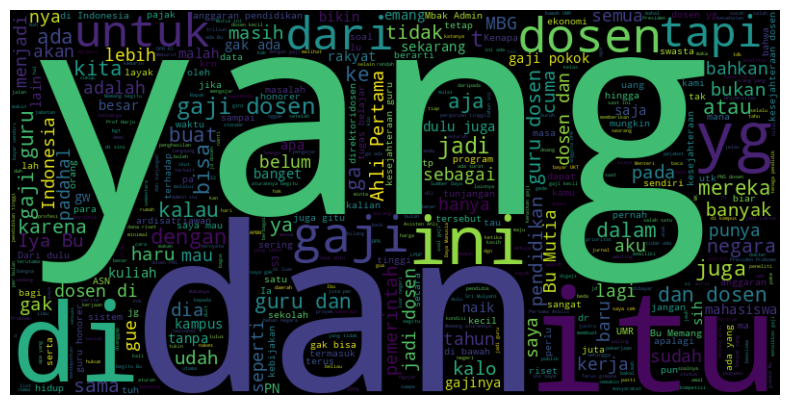

In [ ]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

df['text'] = df['text'].fillna('')

text = ' '.join(df['text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])
wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)
wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

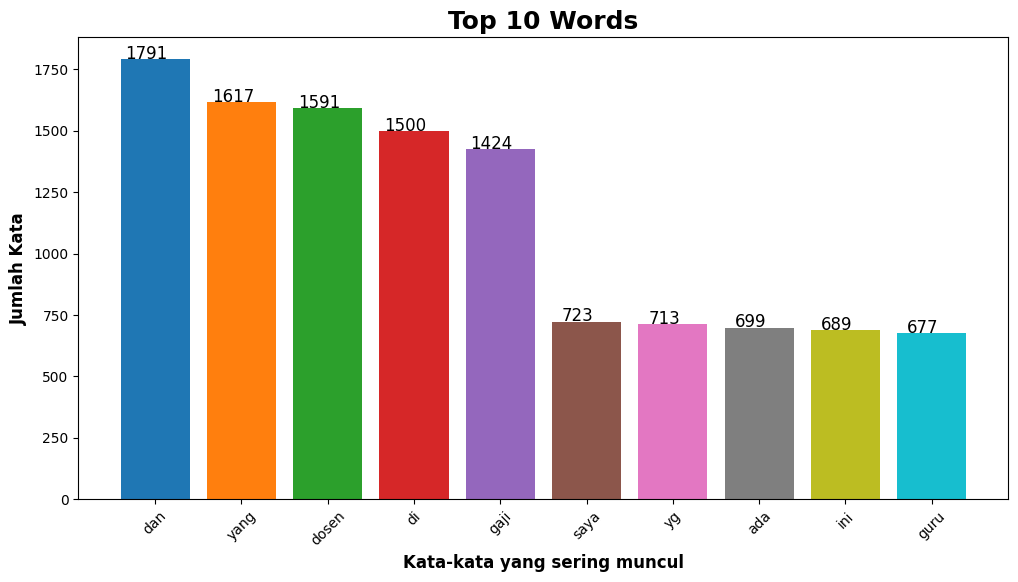

In [ ]:
from collections import Counter

text = " ".join(df['text'])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel('Kata-kata yang sering muncul', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Kata', fontsize=12, fontweight='bold')
plt.title('Top 10 Words', fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

for bar, num in zip (bars, count):
  plt.text(bar.get_x() + bar.get_width()/2 - 0.1 , num + 1, str(num), fontsize=12, color='black', ha='center')

plt.show()

### PROCESSING

Proses Cleanning

In [8]:
import re,string,nltk

def remove_URL(tweet):
  if tweet is not None and isinstance(tweet, str):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'', tweet)
  else:
    return ""

def remove_html(tweet):
  if tweet is not None and isinstance(tweet, str):
    html = re.compile(r'<.*?>')
    return html.sub(r'', tweet)
  else:
    return ""

def remove_emoji(tweet):
  if tweet is not None and isinstance(tweet, str):
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F" # emoticons
        u"\U0001F300-\U0001F5FF" # symbols & pictographs
        u"\U0001F680-\U0001F6FF" # transport & map symbols
        u"\U0001F700-\U0001F77F" # alchemical symbols
        u"\U0001F780-\U0001F7FF" # Geometric Shape and pictographs
        u"\U0001F800-\U0001F8FF" # Supplemental Arrows-C
        u"\U0001F900-\U0001F9FF" # Supplemental Symbols and pictographs
        u"\U0001FA00-\U0001FA6F" # Chess Symbols
        u"\U0001FA70-\U0001FAFF" # Symbols and pictograohs Extended-A
        u"\U0001F004-\U0001F0CF" # Additional emoticons
        u"\U0001F004-\U0001F0CF" # flags
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', tweet)
  else:
    return ""

def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        # PERBAIKAN: Gunakan ' ' (spasi) agar kata tidak menempel
        tweet = re.sub(r'[^a-zA-Z0-9\s]', ' ', tweet)
        # PERBAIKAN: Kembalikan variabel tweet, bukan string kosong
        return tweet
    else:
        return ""

def remove_numbers(tweet):
  if tweet is not None and isinstance(tweet, str):
    tweet = re.sub(r'\b\d+\b', '', tweet)
    tweet = re.sub(r'\s+', ' ', tweet).strip()
    return tweet
  return ""


def remove_username(tweet):
  if tweet is not None and isinstance(tweet, str):
    tweet = re.sub(r'@[^\s]+', '', tweet)
    tweet = re.sub(r'\brt\b', '', tweet, flags=re.IGNORECASE)
    return tweet
  return ""



df['cleaning'] = df['text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_username(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df['cleaning'] = df['cleaning'].str.strip()
df = df[df['cleaning'] != '']

# hapus NaN pada kolom cleaning
df = df.dropna(subset=['cleaning'])
df = df.drop_duplicates(keep='first')


df.head(30)

,tanggal,waktu,text,cleaning
0,Tue Jun 09,10:01:44,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...
1,Tue Jun 09,06:59:34,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...
2,Tue Jun 09,06:57:12,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...
3,Tue Jun 09,06:53:19,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...
4,Tue Jun 09,05:41:06,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...
5,Tue Jun 09,00:07:57,"@ardisatriawan Ikut prihatin 🙏\nTapi, pas guru...",Ikut prihatin Tapi pas guru dan dosen bersuara...
6,Mon Jun 08,18:06:50,"All the while, kesejahteraan pengajarnya sendi...",All the while kesejahteraan pengajarnya sendir...
7,Mon Jun 08,13:24:41,"@dosenkesmas Gaji dosen tipis yaa, makanya do ...",Gaji dosen tipis yaa makanya do everything bua...
8,Mon Jun 08,10:04:12,@nananinuuu17 Dosen gaji buta,Dosen gaji buta
9,Mon Jun 08,09:56:27,"Bukan sekarang gaji dosen murah, mbak. Sini sa...",Bukan sekarang gaji dosen murah mbak Sini saya...


In [10]:
def case_folding(text):
  if isinstance(text, str):
    return text.lower()
  else:
    return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,tanggal,waktu,text,cleaning,case_folding
0,Tue Jun 09,10:01:44,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...
1,Tue Jun 09,06:59:34,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...
2,Tue Jun 09,06:57:12,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...,ga samsek bagus kalo anggarannya bisa dialihka...
3,Tue Jun 09,06:53:19,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...,mau tnya doang semisal minta pndidikan gratis ...
4,Tue Jun 09,05:41:06,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...


In [11]:
import requests as request
from io import BytesIO

def replace_tweet_words(text, kamus_tidak_baku):
    if not isinstance(text, str) or not text.strip():
        return '', [], [], []


    tokens = str(text).split()

    replaced_words = []
    kata_diganti = []
    kata_baku_terganti = []
    kata_tidak_baku_hash = []

    for token in tokens:
        token_lower = token.lower()

        # Cek ke kamus kata baku
        if token_lower in kamus_tidak_baku:
            baku_word = kamus_tidak_baku[token_lower]

            if isinstance(baku_word, str):
                replaced_words.append(baku_word)
                kata_diganti.append(token)
                kata_baku_terganti.append(baku_word)
                kata_tidak_baku_hash.append(hash(token_lower))
            else:
                replaced_words.append(token)
        else:
            replaced_words.append(token)

    # Menggabungkan kembali token menjadi kalimat dan merapikan spasi sebelum tanda baca
    replaced_text = ' '.join(replaced_words)
    return replaced_text, kata_baku_terganti, kata_diganti, kata_tidak_baku_hash

# ==========================================
# PROSES LOADING KAMUS DAN EKSEKUSI DATA X
# ==========================================
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = request.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

kamus_tidak_baku_dict = dict(zip(
    kamus_data['tidak_baku'].astype(str).str.lower(),
    kamus_data['kata_baku'].astype(str)
))

# Jalankan pada dataframe tweet Anda (pastikan kolom case_folding sudah ada)
# Ganti nama 'data' dan 'case_folding' sesuai dataframe Anda jika berbeda
output_series = df['case_folding'].apply(lambda x: replace_tweet_words(x, kamus_tidak_baku_dict))

df['normalisasi'] = output_series.apply(lambda x: x[0])
df['kata_baku'] = output_series.apply(lambda x: x[1])
df['kata_tidak_baku'] = output_series.apply(lambda x: x[2])
df['kata_Tidak_Baku_hash'] = output_series.apply(lambda x: x[3])

# Cetak hasil untuk pengecekan Bab 4 Tugas Akhir
df = pd.DataFrame(df[['text', 'cleaning', 'case_folding', 'normalisasi']])

# Menampilkan 5 baris teratas ke layar Google Colab / Jupyter
df.head(5)

,text,cleaning,case_folding,normalisasi
0,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...,i admired my mom sok much lowk lulusan s2 pern...
1,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...
2,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...,ga samsek bagus kalo anggarannya bisa dialihka...,tidak samsek bagus kalau anggarannya bisa dial...
3,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...,mau tnya doang semisal minta pndidikan gratis ...,mau tanya doang semisal meminta pndidikan grat...
4,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak ya bikin proker tanpa ada skala prioritas...


In [ ]:
from deep_translator import GoogleTranslator
import pandas as pd
import re
import time

# =========================================================================
# 1. LAPIS 1: PRE-TRANSLATE NORMALIZATION (MENGAMANKAN ISTILAH AKADEMIS)
# =========================================================================
def pre_translate_normalization(text):
    if not isinstance(text, str):
        return ""
    # Mengubah istilah S1/S2/S3 menjadi frasa utuh agar Google Translate tidak bingung
    text = re.sub(r'\bs1s2\b', 'bachelor and master degree', text, flags=re.IGNORECASE)
    text = re.sub(r'\bs2s3\b', 'master and doctoral degree', text, flags=re.IGNORECASE)
    text = re.sub(r'\bs1\b', 'bachelor degree', text, flags=re.IGNORECASE)
    text = re.sub(r'\bs2\b', 'master degree', text, flags=re.IGNORECASE)
    text = re.sub(r'\bs3\b', 'doctoral degree', text, flags=re.IGNORECASE)
    text = re.sub(r'\bd3\b', 'diploma degree', text, flags=re.IGNORECASE)
    return text

# Terapkan perbaikan pada kolom normalisasi sebelum masuk proses unik
df['normalisasi_fixed'] = df['normalisasi'].apply(pre_translate_normalization)

# =========================================================================
# 2. IDENTIFIKASI BAHASA & ISOLASI KALIMAT UNIK
# =========================================================================
df_normalisasi = pd.DataFrame(df['normalisasi_fixed'].astype(str))
unique_elements = df_normalisasi['normalisasi_fixed'].unique()

print(f"Menemukan {len(unique_elements)} kalimat unik dari total {len(df_normalisasi)} baris data.")
print("Memulai proses penerjemahan otomatis ke Bahasa Inggris...\n")

# =========================================================================
# 3. PROSES PENERJEMAHAN MASAL MENGGUNAKAN DICTIONARY MAPPING
# =========================================================================
translations = {}

for element in unique_elements:
    text_strip = str(element).strip()

    if not text_strip:
        translations[element] = ""
        continue

    try:
        # Tambahkan jeda 0.05 detik agar koneksi tidak diputus paksa (rate limit) oleh API
        time.sleep(0.05)
        translated_text = GoogleTranslator(source='auto', target='en').translate(text_strip)
        translations[element] = translated_text
    except Exception as e:
        translations[element] = element

# Memasukkan hasil terjemahan dari kamus lokal ke kolom baru 'translated_text'
df['translated_text'] = df_normalisasi['normalisasi_fixed'].map(translations)

# =========================================================================
# 4. LAPIS 2: POST-TRANSLATE CLEANING & ARTIFACT REMOVAL
# =========================================================================
def post_translate_cleaning(text):
    if not isinstance(text, str):
        return ""

    # a. Paksa ubah residu bahasa Indonesia yang lolos dari terjemahan
    text = re.sub(r'\bdosen\b', 'lecturer', text, flags=re.IGNORECASE)
    text = re.sub(r'\bgaji\b', 'salary', text, flags=re.IGNORECASE)

    # b. Cleansing akhir: hapus sisa tanda baca (termasuk apostrof) dan lowercasing
    text = re.sub(r'([^0-9A-Za-z \t])|(\w+:\/\/\S+)', ' ', text)
    text = text.lower()

    # c. Hapus artefak huruf 's' tunggal akibat hilangnya apostrof (misal: master's -> master s)
    text = re.sub(r'\b s \b', ' ', text)

    # d. Menghilangkan spasi ganda
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Terapkan pembersihan pasca-translasi
df['translated_text'] = df['translated_text'].apply(post_translate_cleaning)

print("✓ Tahap Translation Berhasil Diselesaikan Tanpa Kebocoran Bahasa!")

# =========================================================================
# 5. OUTPUT TAMPILAN UNTUK SUB-BAB HASIL DAN PEMBAHASAN LAPORAN TA
# =========================================================================
df_display = pd.DataFrame(df[['text', 'normalisasi', 'translated_text']])
df_display.head(5)

Menemukan 1742 kalimat unik dari total 1759 baris data.
Memulai proses penerjemahan otomatis ke Bahasa Inggris...



In [ ]:
def tokenize(text):
  tokens = text.split()
  return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)
df.head(5)

,text,cleaning,case_folding,normalisasi,tokenize
0,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...,i admired my mom sok much lowk lulusan s2 pern...,"[i, admired, my, mom, sok, much, lowk, lulusan..."
1,"@abdimuda_id gua sih berharap, guru dan dosen ...",abdimudaid gua sih berharap guru dan dosen hon...,abdimudaid gua sih berharap guru dan dosen hon...,abdimudaid gua sih berharap guru dan dosen hon...,"[abdimudaid, gua, sih, berharap, guru, dan, do..."
2,@ardisatriawan Ga samsek. Bagus kalo anggarann...,ardisatriawan Ga samsek Bagus kalo anggarannya...,ardisatriawan ga samsek bagus kalo anggarannya...,ardisatriawan tidak samsek bagus kalau anggara...,"[ardisatriawan, tidak, samsek, bagus, kalau, a..."
3,"@denni_sauya Mau tnya doang, semisal minta pnd...",dennisauya Mau tnya doang semisal minta pndidi...,dennisauya mau tnya doang semisal minta pndidi...,dennisauya mau tanya doang semisal meminta pnd...,"[dennisauya, mau, tanya, doang, semisal, memin..."
4,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak ya bikin proker tanpa ada skala prioritas...,"[enak, ya, bikin, proker, tanpa, ada, skala, p..."


In [ ]:
import pandas as pd
import re

# =========================================================================
# 1. KAMUS SINONIM TERKONTROL (BERDASARKAN OUTPUT CLAUDE)
# =========================================================================
synonym_mapping = {
    # a. Kluster Pengajar/Akademisi -> Target Induk: lecturer
    'lecturers': 'lecturer', 'professor': 'lecturer', 'professors': 'lecturer',
    'prof': 'lecturer', 'tutor': 'lecturer', 'tutors': 'lecturer',
    'instructor': 'lecturer', 'instructors': 'lecturer', 'educator': 'lecturer',
    'educators': 'lecturer', 'academic': 'lecturer', 'academics': 'lecturer',
    'academician': 'lecturer', 'faculty': 'lecturer', 'faculties': 'lecturer',
    'teacher': 'lecturer', 'teachers': 'lecturer', 'lecturing': 'lecturer',

    # b. Kluster Finansial/Kesejahteraan -> Target Induk: salary & welfare
    'salaries': 'salary', 'wage': 'salary', 'wages': 'salary',
    'income': 'salary', 'incomes': 'salary', 'pay': 'salary',
    'paid': 'salary', 'paying': 'salary', 'paycheck': 'salary',
    'fee': 'salary', 'honorarium': 'salary', 'honorariums': 'salary',
    'honorary': 'salary', 'honor': 'salary', 'remuneration': 'salary',
    'compensation': 'salary', 'allowance': 'salary', 'allowances': 'salary',
    'stipend': 'salary', 'tukin': 'salary', 'bonus': 'salary',
    'bonuses': 'salary', 'reward': 'salary', 'rewards': 'salary',
    'pension': 'salary', 'pensions': 'salary',
    'prosperity': 'welfare', 'livelihood': 'welfare',

    # c. Kluster Institusi/Tempat Kerja -> Target Induk: institution
    'university': 'institution', 'universities': 'institution', 'college': 'institution',
    'colleges': 'institution', 'campus': 'institution', 'campuses': 'institution',
    'school': 'institution', 'schools': 'institution', 'institutions': 'institution',
    'sd': 'institution','dpr': 'government',

    # d. Kluster Sistem & Status Kepegawaian -> Target Induk: system & status
    'application': 'system', 'app': 'system', 'apps': 'system', 'platform': 'system',
    'systems': 'system', 'sister': 'system', 'siakad': 'system', 'sinta': 'system',
    'bkd': 'system', 'dapodik': 'system', 'feeder': 'system',
    'pppk': 'status', 'pns': 'status', 'asn': 'status', 'civil servant': 'status',
    'civil servants': 'status', 'servant': 'status', 'servants': 'status',
    'non asn': 'status', 'tenure': 'status', 'tenured': 'status'
}

# =========================================================================
# 2. FUNGSI SUBSTITUSI SINONIM
# =========================================================================
def apply_claude_synonyms(text, synonym_dict):
    # Proteksi jika ada nilai kosong
    if pd.isna(text) or not isinstance(text, str) or not text.strip():
        return ""

    # TANGANI FRASA MULTI-KATA DULU (agar tidak rusak saat di-split)
    # Contoh: 'civil servant' diubah menjadi 'status'
    phrases_to_replace = [
        ('civil servant', 'status'),
        ('civil servants', 'status'),
        ('non asn', 'status')
    ]
    for phrase, target in phrases_to_replace:
        text = re.sub(r'\b' + phrase + r'\b', target, text, flags=re.IGNORECASE)

    # Eksekusi penggantian kata tunggal
    words = text.split()
    replaced_words = []

    for word in words:
        word_lower = word.lower()
        if word_lower in synonym_dict:
            replaced_words.append(synonym_dict[word_lower])
        else:
            replaced_words.append(word)

    return ' '.join(replaced_words)

# =========================================================================
# 3. EKSEKUSI PADA DATAFRAME
# =========================================================================
print("Menjalankan tahap substitusi sinonim (Densifikasi Vektor)...")

# Menerapkan fungsi ke kolom translated_text
df['synonym'] = df['translated_text'].apply(lambda x: apply_claude_synonyms(x, synonym_mapping))

print("✓ Tahap Substitusi Sinonim Selesai! Korpus data Anda telah ter-densifikasi dengan aman.")

# =========================================================================
# 4. TAMPILAN UNTUK LAPORAN BAB 4
# =========================================================================
# Menampilkan komparasi 3 tahap terakhir untuk screenshot laporan
df_display_synonym = pd.DataFrame(df)
df_display_synonym.head(10)

Menjalankan tahap substitusi sinonim (Densifikasi Vektor)...
✓ Tahap Substitusi Sinonim Selesai! Korpus data Anda telah ter-densifikasi dengan aman.


,text,cleaning,case_folding,normalisasi,normalisasi_fixed,translated_text,synonym,stopword_removal
0,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...,i admired my mom sok much lowk lulusan s2 pern...,i admired my mom sok much lowk lulusan master ...,i admire my mom so much lowk master degree gra...,i admire my mom so much lowk master degree gra...,admire mom lowk master degree graduate lecture...
1,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,i really hope that honorary teachers and lectu...,i really hope that salary lecturer and lecture...,hope salary lecturer lecturer appointed status...
2,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...,ga samsek bagus kalo anggarannya bisa dialihka...,tidak samsek bagus kalau anggarannya bisa dial...,tidak samsek bagus kalau anggarannya bisa dial...,it wouldn t be a good thing if the budget coul...,it wouldn t be a good thing if the budget coul...,thing budget diverted provide decent salary le...
3,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...,mau tnya doang semisal minta pndidikan gratis ...,mau tanya doang semisal meminta pndidikan grat...,mau tanya doang semisal meminta pndidikan grat...,i just want to ask for example asking for free...,i just want to ask for example asking for free...,ask example asking free education pays lecture...
4,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak ya bikin proker tanpa ada skala prioritas...,enak ya bikin proker tanpa ada skala prioritas...,it nice to make work programs without any prio...,it nice to make work programs without any prio...,nice work programs without priority scale supp...
5,"@ardisatriawan Ikut prihatin 🙏\nTapi, pas guru...",Ikut prihatin Tapi pas guru dan dosen bersuara...,ikut prihatin tapi pas guru dan dosen bersuara...,ikut prihatin tapi pas guru dan dosen bersuara...,ikut prihatin tapi pas guru dan dosen bersuara...,i m also concerned but when teachers and lectu...,i m also concerned but when lecturer and lectu...,concerned lecturer lecturer speak welfare beli...
6,"All the while, kesejahteraan pengajarnya sendi...",All the while kesejahteraan pengajarnya sendir...,all the while kesejahteraan pengajarnya sendir...,all the while kesejahteraan pengajarnya sendir...,all the while kesejahteraan pengajarnya sendir...,all the while the welfare of the teachers them...,all the while the welfare of the lecturer them...,welfare lecturer increase proportion increase ...
7,"@dosenkesmas Gaji dosen tipis yaa, makanya do ...",Gaji dosen tipis yaa makanya do everything bua...,gaji dosen tipis yaa makanya do everything bua...,gaji dosen tipis ya makanya di everything buat...,gaji dosen tipis ya makanya di everything buat...,lecturer salaries are low that why everything ...,lecturer salary are low that why everything is...,lecturer salary low everything engagement
8,@nananinuuu17 Dosen gaji buta,Dosen gaji buta,dosen gaji buta,dosen gaji buta,dosen gaji buta,blind salary lecturers,blind salary lecturer,blind salary lecturer
9,"Bukan sekarang gaji dosen murah, mbak. Sini sa...",Bukan sekarang gaji dosen murah mbak Sini saya...,bukan sekarang gaji dosen murah mbak sini saya...,bukan sekarang gaji dosen murah mbak sini saya...,bukan sekarang gaji dosen murah mbak sini saya...,not now lecturer salaries are cheap sis here i...,not now lecturer salary are cheap sis here i c...,lecturer salary cheap correct editorial ukt ex...


In [ ]:
from nltk.corpus import stopwords
import nltk
import pandas as pd

# Download kamus jika belum
nltk.download('stopwords')

# Set stopword NLTK English
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Proteksi jika ada baris kosong
    if pd.isna(text) or not isinstance(text, str):
        return []

    # PERBAIKAN: Gunakan .split() agar teks dibaca per kata, bukan per huruf
    return [word for word in text.split() if word.lower() not in stop_words]

# Terapkan ke dataframe
df['stopword_removal'] = df['synonym'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

# Tampilkan hasilnya
df_display = pd.DataFrame(df[['synonym', 'stopword_removal']])
df_display.head(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,synonym,stopword_removal
0,i admire my mom so much lowk master degree gra...,admire mom much lowk master degree graduate le...
1,i really hope that salary lecturer and lecture...,really hope salary lecturer lecturer appointed...
2,it wouldn t be a good thing if the budget coul...,good thing budget could diverted provide decen...
3,i just want to ask for example asking for free...,want ask example asking free education pays le...
4,it nice to make work programs without any prio...,nice make work programs without priority scale...


In [ ]:
from collections import Counter


all_text = ' '.join(df['stopword_removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text)

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekquensi'])

df_freq.to_csv('frekquensi_kata_Awal.csv', index=False)
print("File berhasil tersimpan")
df_freq.info()
df_freq.head(50)

File berhasil tersimpan
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8989 entries, 0 to 8988
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Kata        8989 non-null   object
 1   Frekquensi  8989 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 140.6+ KB


,Kata,Frekquensi
0,lecturer,4085
1,salary,3092
2,institution,884
3,bu,704
4,saya,600
5,status,540
6,education,475
7,even,411
8,people,361
9,also,354


In [ ]:
import pandas as pd
import re

hapus_kata = [
    # Filler Inggris
    'even', 'also', 'like', 'really', 'get', 'got', 'would', 'could',
    'make', 'made', 'one', 'two', 'go', 'going', 'say', 'said', 'want',
    'know', 'think', 'well', 'much', 'many', 'way', 'something', 'anything',
    'people', 'still', 'though', 'become', 'yes', 'small', 'year', 'state',
    'first', 'good', 'right', 'take', 'must', 'per', 'sir', 'sis', 'lowk',

    # Residu Filler Indonesia & Simbol
    'bu', 'saya', 'begitu', 'ada', 'ini', 'iya', 'tidak', 'yang', 'di',
    'mbak', 'ya', 'pertama', 'jadi', 'sudah', 'memang', 'dulu',
    'dari', 'sama', 'bisa', 'pak', 'juga', 'kan', 'itu', 'bagaimana',
    'dan', 'harus', 'lagi', 'mutia', 'rp', 'idr', 'oh'
]

# 1. KODE PENGHAPUSAN YANG AMAN (Dilengkapi proteksi baris kosong dan lowercasing)
df['stopword_removal'] = df['stopword_removal'].apply(
    lambda x: ' '.join([word for word in str(x).split() if word.lower() not in hapus_kata]) if pd.notna(x) else ""
)

# 2. KODE PENGECEKAN YANG BENAR (Menggunakan Regex Word Boundary \b)
# Kita buat pola regex: \b(even|also|like|...|di|oh)\b
pattern = r'\b(?:' + '|'.join(hapus_kata) + r')\b'

# Hitung baris yang benar-benar masih mengandung KATA UTUH dari list tersebut
jumlah_bocor = df['stopword_removal'].str.contains(pattern, case=False, regex=True).sum()

print(f"Jumlah baris yang masih mengandung kata ampas: {jumlah_bocor}")

# Opsional: Jika Anda ingin melihat kata apa saja yang paling banyak tersisa,
# Anda bisa menjalankan ulang kode pengecekan frekuensi (Counter) yang kita buat sebelumnya.

Jumlah baris yang masih mengandung kata ampas: 0


In [ ]:
df.head(5)

,text,cleaning,case_folding,normalisasi,normalisasi_fixed,translated_text,synonym,stopword_removal,tokenize
0,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...,i admired my mom sok much lowk lulusan s2 pern...,i admired my mom sok much lowk lulusan master ...,i admire my mom so much lowk master degree gra...,i admire my mom so much lowk master degree gra...,admire mom master degree graduate lecturer fig...,"[admire, mom, lowk, master, degree, graduate, ..."
1,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,i really hope that honorary teachers and lectu...,i really hope that salary lecturer and lecture...,hope salary lecturer lecturer appointed status...,"[hope, salary, lecturer, lecturer, appointed, ..."
2,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...,ga samsek bagus kalo anggarannya bisa dialihka...,tidak samsek bagus kalau anggarannya bisa dial...,tidak samsek bagus kalau anggarannya bisa dial...,it wouldn t be a good thing if the budget coul...,it wouldn t be a good thing if the budget coul...,thing budget diverted provide decent salary le...,"[thing, budget, diverted, provide, decent, sal..."
3,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...,mau tnya doang semisal minta pndidikan gratis ...,mau tanya doang semisal meminta pndidikan grat...,mau tanya doang semisal meminta pndidikan grat...,i just want to ask for example asking for free...,i just want to ask for example asking for free...,ask example asking free education pays lecture...,"[ask, example, asking, free, education, pays, ..."
4,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak ya bikin proker tanpa ada skala prioritas...,enak ya bikin proker tanpa ada skala prioritas...,it nice to make work programs without any prio...,it nice to make work programs without any prio...,nice work programs without priority scale supp...,"[nice, work, programs, without, priority, scal..."


In [ ]:
from collections import Counter
import pandas as pd

# 1. Langsung gabungkan teks tanpa manipulasi regex lagi
all_text = ' '.join(df['stopword_removal'].astype(str))

# 2. Hitung kata
word_list = all_text.split()
word_freq = Counter(word_list)

# 3. Urutkan dan simpan ke CSV
sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekquensi'])

df_freq.to_csv('frekquensi_kata_Awal3_Jujur.csv', index=False)
print("File berhasil tersimpan! Silakan cek kata 'rp' apakah wujud aslinya pakai angka.")
df_freq.head(50)

File berhasil tersimpan! Silakan cek kata 'rp' apakah wujud aslinya pakai angka.


,Kata,Frekquensi
0,lecturer,4085
1,salary,3092
2,institution,884
3,status,540
4,education,475
5,government,336
6,welfare,335
7,degree,304
8,indonesia,239
9,work,233


In [ ]:
def tokenize(text):
  tokens = text.split()
  return tokens

df['tokenize'] = df['stopword_removal'].apply(tokenize)
df.head(5)

,text,cleaning,case_folding,normalisasi,normalisasi_fixed,translated_text,synonym,stopword_removal,tokenize
0,"i admired my mom so much lowk… lulusan s2, per...",i admired my mom so much lowk lulusan s2 perna...,i admired my mom so much lowk lulusan s2 perna...,i admired my mom sok much lowk lulusan s2 pern...,i admired my mom sok much lowk lulusan master ...,i admire my mom so much lowk master degree gra...,i admire my mom so much lowk master degree gra...,admire mom master degree graduate lecturer fig...,"[admire, mom, master, degree, graduate, lectur..."
1,"@abdimuda_id gua sih berharap, guru dan dosen ...",gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,gua sih berharap guru dan dosen honorer bisa d...,i really hope that honorary teachers and lectu...,i really hope that salary lecturer and lecture...,hope salary lecturer lecturer appointed status...,"[hope, salary, lecturer, lecturer, appointed, ..."
2,@ardisatriawan Ga samsek. Bagus kalo anggarann...,Ga samsek Bagus kalo anggarannya bisa dialihka...,ga samsek bagus kalo anggarannya bisa dialihka...,tidak samsek bagus kalau anggarannya bisa dial...,tidak samsek bagus kalau anggarannya bisa dial...,it wouldn t be a good thing if the budget coul...,it wouldn t be a good thing if the budget coul...,thing budget diverted provide decent salary le...,"[thing, budget, diverted, provide, decent, sal..."
3,"@denni_sauya Mau tnya doang, semisal minta pnd...",Mau tnya doang semisal minta pndidikan gratis ...,mau tnya doang semisal minta pndidikan gratis ...,mau tanya doang semisal meminta pndidikan grat...,mau tanya doang semisal meminta pndidikan grat...,i just want to ask for example asking for free...,i just want to ask for example asking for free...,ask example asking free education pays lecture...,"[ask, example, asking, free, education, pays, ..."
4,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak yah bikin proker tanpa ada skala priorita...,enak ya bikin proker tanpa ada skala prioritas...,enak ya bikin proker tanpa ada skala prioritas...,it nice to make work programs without any prio...,it nice to make work programs without any prio...,nice work programs without priority scale supp...,"[nice, work, programs, without, priority, scal..."


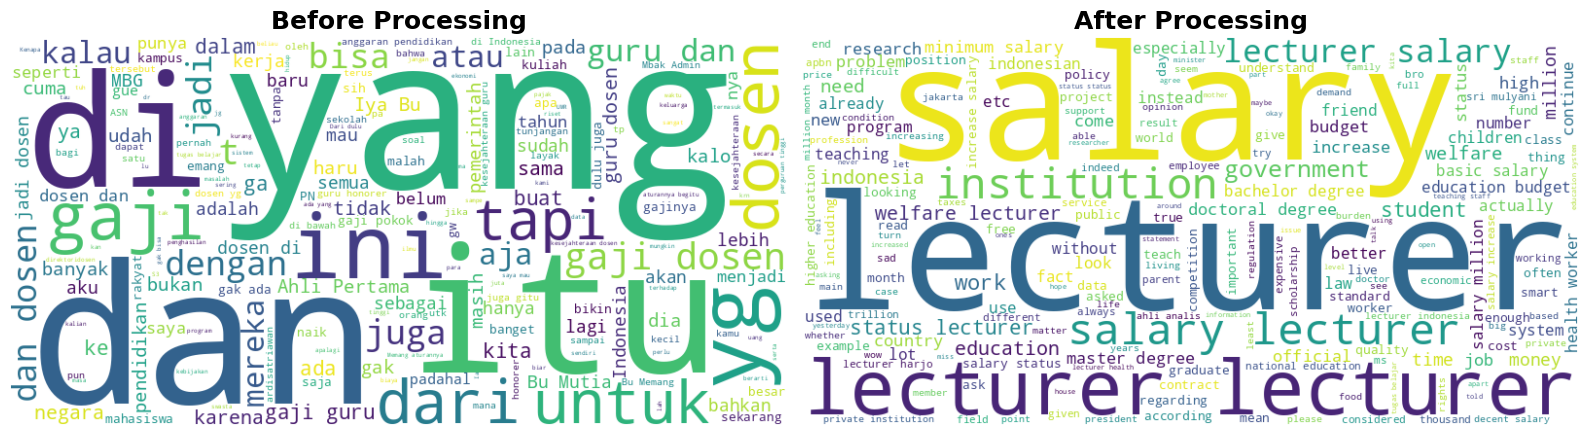

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import pandas as pd

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

text_before = ' '.join(df['text'].astype(str).tolist())

wc_before = WordCloud(stopwords=stopwords, background_color="white", max_words=200, width=800, height=400).generate(text_before)

text_after = ' '.join(df['stopword_removal'].astype(str).tolist())

wc_after = WordCloud(stopwords=stopwords, background_color="white", max_words=200, width=800, height=400).generate(text_after)

plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title('Before Processing', fontsize=18, fontweight='bold')

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title('After Processing', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

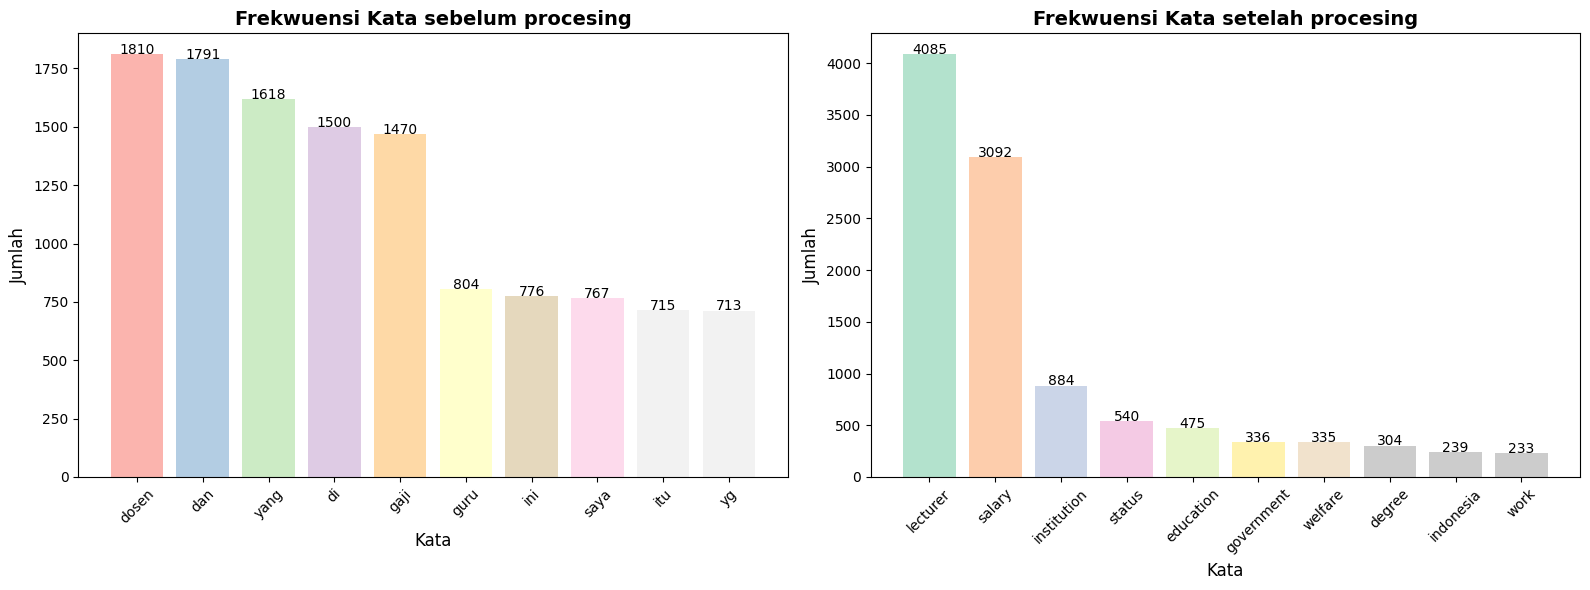

In [ ]:
def clean_text_coloumn(series):
  cleaned = []
  for text in series.astype(str):
      text = re.sub(r"[\[\]\'\",]","",text)
      cleaned.append(text.strip())
  return " ".join(cleaned)

# before
all_text_before = clean_text_coloumn(df['text'])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# after
all_text_after = clean_text_coloumn(df['stopword_removal'])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# before plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title('Frekwuensi Kata sebelum procesing', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Kata', fontsize=12)
axes[0].set_ylabel('Jumlah', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

for bar, count in zip(bars1, count_before):
  axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')


# after plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title('Frekwuensi Kata setelah procesing', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Kata', fontsize=12)
axes[1].set_ylabel('Jumlah', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

for bar, count in zip(bars2, count_after):
  axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('hasil_processing_Data.csv', encoding='utf8', index=False)
print("File berhasil tersimpan")

File berhasil tersimpan


### residu pembersihan

In [ ]:
df = pd.read_csv('hasil_processing_Data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1775 entries, 0 to 1774
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               1775 non-null   object
 1   cleaning           1755 non-null   object
 2   case_folding       1755 non-null   object
 3   normalisasi        1755 non-null   object
 4   normalisasi_fixed  1755 non-null   object
 5   translated_text    1755 non-null   object
 6   synonym            1755 non-null   object
 7   stopword_removal   1755 non-null   object
 8   tokenize           1775 non-null   object
dtypes: object(9)
memory usage: 124.9+ KB


In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 21.9 MB/s eta 0:00:00


In [1]:
ls

 data_kesejahteraan_dosen.xlsx  'Percobaan_Sentimen_2 update2.ipynb'*   tes/
 myenv/                          scrapping_x.ipynb


In [ ]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from gensim import corpora

nltk.download('stopwords')

# =========================================================================
# 1. MENGATASI BARIS KOSONG & DEDUPLIKASI RETWEET (Isu 1 & 2 Claude)
# =========================================================================
# Hapus dokumen kosong (efek dari pembersihan font miring/link pada tahap awal)
df = df.dropna(subset=['stopword_removal'])
df = df[df['stopword_removal'].str.strip() != '']

# Deduplikasi: Menghapus retweet/copy-paste berulang dari thread viral
df = df.drop_duplicates(subset=['text'], keep='first')
print(f"Total baris setelah pembersihan awal (Drop NaN & Duplikat): {len(df)}")

# =========================================================================
# 2. PASS KE-2: STOPWORD INDONESIA UNTUK RESIDU (Isu 3 Claude)
# =========================================================================
stop_words_id = set(stopwords.words('indonesian'))
custom_residu = {
    'kalau', 'kita', 'bayar', 'ahli', 'admin', 'belum', 'untuk', 'tapi', 'ke',
    'rp', 'idr', 'dpr', 'sd', 'mutia', 'nya', 'yg', 'aja', 'gak', 'kalo'
}
final_residu_stopwords = stop_words_id.union(custom_residu)

def clean_residu(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    filtered = [w for w in words if w.lower() not in final_residu_stopwords]
    return " ".join(filtered)

df['stopword_removal'] = df['stopword_removal'].apply(clean_residu)
df = df[df['stopword_removal'].str.strip() != '']

# =========================================================================
# 3. SEGMENTASI DOKUMEN MAX 20 KATA (Isu 2 Claude - Patuh Metodologi Paper)
# =========================================================================
def segment_text(text, max_words=20):
    words = text.split()
    if len(words) <= max_words:
        return [text]
    # Memecah 1 kalimat panjang menjadi beberapa potongan maksimal 20 kata
    return [' '.join(words[i:i + max_words]) for i in range(0, len(words), max_words)]

df['segmented_text'] = df['stopword_removal'].apply(lambda x: segment_text(str(x), max_words=20))

# 'Explode' berfungsi agar list hasil pecahan tadi turun menjadi baris-baris mandiri di dataframe
df_lda = df.explode('segmented_text').reset_index(drop=True)

# Tokenisasi final untuk menyiapkan format list bagi library Gensim
df_lda['tokenize_final'] = df_lda['segmented_text'].apply(lambda x: str(x).split())
print(f"Total dokumen setelah segmentasi (Siap LDA): {len(df_lda)}")

# =========================================================================
# 4. PERSIAPAN DICTIONARY GENSIM & FILTER EXTREMES (Isu 4 Claude)
# =========================================================================
dictionary = corpora.Dictionary(df_lda['tokenize_final'])
print(f"Jumlah Kosakata Unik SEBELUM Filter: {len(dictionary)}")

# Menjinakkan token super dominan (seperti 'lecturer', 'status') agar topik tidak bias
# no_below=5: Buang kata yang muncul di kurang dari 5 dokumen (biasanya salah ketik/typo)
# no_above=0.4: Buang kata yang mendominasi di lebih dari 40% total dokumen (terlalu umum)
dictionary.filter_extremes(no_below=5, no_above=0.4)
print(f"Jumlah Kosakata Unik SETELAH Filter: {len(dictionary)}")

# Pembuatan Corpus (Bag of Words) yang menjadi input utama model LDA
corpus = [dictionary.doc2bow(text) for text in df_lda['tokenize_final']]
print("✓ Korpus dan Dictionary LDA Berhasil Dibuat Secara Optimal!")

ModuleNotFoundError: No module named 'gensim'